In [1]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
from datetime import date

import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter

import eurostat #python wrapper for taking data. 
import time

In [2]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals' #Gio
# Share_point = r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals' #Ugne

In [6]:
import os
os.chdir(Share_point)

In [7]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\LNG terminals'

In [8]:
Points_APIs = pd.read_excel(r'Dataproviders 09.05.2023.xlsx',sheet_name='LNG terminals')

### key for version 6 and 7 of the API calls GIE

In [9]:
headers = {"x-key":"d8561648296cb38e6c400823755689941530"} # After July 4th 2022
# ideally each user should have its own API key

### Restart here

In [10]:
d1 = '2023-07-01'
d2 = '2023-12-31' # To change in the new year

In [11]:
dates = []
sendOut = []
stored = []
max_storage = []
max_sendout =[]
country = []
Name = []

for item in range(len(Points_APIs)):
        url = Points_APIs.iloc[item,3]+'&from={}&to={}&size=300'.format(d1,d2)
        try:
            r = requests.get(url,headers=headers)
            if r.status_code != 200:
                print(r.status_code)
                print(url)

            raw_data = r.json()
            inner_data = raw_data['data']
            for x in inner_data:
                #here we work with the APIs
                date = x['gasDayStart'] 
                inventory = x['inventory']
                sendOuts = x['sendOut']
                Max_Storage = x['dtmi']
                Max_Sendout = x['dtrs']
                #here we work with the excel file
                countries = Points_APIs.iloc[item,0]
                Names = Points_APIs.iloc[item,5]


                dates.append(date)     
                sendOut.append(sendOuts)
                stored.append(inventory)
                max_storage.append(Max_Storage)
                max_sendout.append(Max_Sendout)
                country.append(countries)
                Name.append(Names)
        except Exception as e:
            print(e)

In [12]:
df = pd.DataFrame()
df['dates'] = dates
df['sendOut'] = sendOut          ## in GWh/d
df['stored'] = stored            ## in 10^3 m^3 LNG
df['Max Storage'] = max_storage  ## in 10^3 m^3 LNG
df['Max Sendout'] = max_sendout  ## in GWh/d
df['country'] = country
df['name'] = Name

In [13]:
df[df['country']=='GR'].head()

,dates,sendOut,stored,Max Storage,Max Sendout,country,name
756,2023-10-16,37,187.23,225,224.6,GR,Revythoussa LNG Terminal
757,2023-10-15,37,187.23,225,224.6,GR,Revythoussa LNG Terminal
758,2023-10-14,37,187.23,225,224.6,GR,Revythoussa LNG Terminal
759,2023-10-13,37,187.23,225,224.6,GR,Revythoussa LNG Terminal
760,2023-10-12,37,187.23,225,224.6,GR,Revythoussa LNG Terminal


In [14]:
# Getting rid of NaNa
df.replace('-', np.NaN,inplace=True)
# Getting rid of observations for which we have no data
# df = df.dropna()

In [15]:
df['sendOut'] = pd.to_numeric(df['sendOut'])
df['stored'] = pd.to_numeric(df['stored'])
df['Max Storage'] = pd.to_numeric(df['Max Storage']) 
df['Max Sendout'] = pd.to_numeric(df['Max Sendout']) 

In [16]:
df.shape

(2916, 7)

In [17]:
from datetime import date
df.to_csv('raw_data/2023_2.csv')

###  merge with historic data

In [18]:
# Change current directory
import os
os.chdir(Share_point + '\\raw_data')

In [19]:
df_1 = pd.read_csv('2015.csv',index_col=0)
df_2 = pd.read_csv('2016.csv',index_col=0)
df_3 = pd.read_csv('2017.csv',index_col=0)
df_4 = pd.read_csv('2018.csv',index_col=0)
df_5a = pd.read_csv('2019_1.csv',index_col=0)
df_5b = pd.read_csv('2019_2.csv',index_col=0)
df_6a = pd.read_csv('2020_1.csv',index_col=0)
df_6b = pd.read_csv('2020_2.csv',index_col=0)
df_7a = pd.read_csv('2021_1.csv',index_col=0)
df_7b = pd.read_csv('2021_2.csv',index_col=0)
df_8a = pd.read_csv('2022_1.csv',index_col=0)
df_8b = pd.read_csv('2022_2.csv',index_col=0)
df_9a = pd.read_csv('2023_1.csv',index_col=0)
df_9b = pd.read_csv('2023_2.csv',index_col=0)

In [20]:
df = pd.concat([df_1,df_2,df_3,df_4,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a,df_9b])

In [21]:
# del df['Unnamed: 0'] #need to run only when importing the data (not downloading from online)
# drops duplicates
df = df.drop_duplicates()

In [22]:
from datetime import date
today = date.today()
# this is used to have Sunday's observation as last ones when running on Wednesday (most recent data often partially missing)
last_obs = today - timedelta(days=3)

In [23]:
df = df.set_index(pd.DatetimeIndex(df['dates']))
del df['dates']
df = df.sort_values(by='dates')

In [25]:
# check countries
df.country.unique()

array(['ES', 'IT', 'FR', 'NL', 'PT', 'GR', 'BE', 'GB', 'LT', 'PL', 'ES*',
       'GB*', 'HR', 'DE'], dtype=object)

In [26]:
# Change current directory
import os
os.chdir(Share_point)

In [30]:
# group by date and country (for countries with multiple terminals)
df_C = df.groupby(['dates','country']).sum().reset_index()
df_C = df_C.set_index(pd.DatetimeIndex(df_C['dates']))

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_29148\4144074994.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_C = df.groupby(['dates','country']).sum().reset_index()


## regassification % - Weekly data

In [ ]:
# Here we are interested in getting the LNG regassification in % of total capacity

In [28]:
from datetime import date
today = date.today()
last_obs = today - timedelta(days=2) # can be also -3
print(last_obs)
# enddate = datetime.strptime('2022-07-17', "%d-%m-%Y") this useful only if done manually
enddate = last_obs
startdate = enddate - timedelta(days=30)

2023-10-16


In [32]:
df_w = df_C.groupby([pd.Grouper(freq='W'),'country']).sum().reset_index()
df_w=df_w.set_index(pd.DatetimeIndex(df_w['dates']))

In [33]:
# check countries
df_w.country.unique()

array(['BE', 'ES', 'FR', 'GB', 'GR', 'IT', 'NL', 'PT', 'LT', 'PL', 'ES*',
       'GB*', 'HR', 'DE'], dtype=object)

In [34]:
df_w = df_w[~df_w.country.isin(['ES*','GB','GB*'])] # Get rid of UK and ES TVB aggregate --> for which there is no data pre-2020

In [35]:
del df_w['dates']

In [39]:
## Can change from new year
data = pd.DataFrame()
data['week'] = list(range(0,54,1))

# plot = df_w.groupby([pd.Grouper(freq='W'),'country']).sum()[:] ## use a converter if you want to transform the data
df_w['week'] = df_w.index.isocalendar().week

hist = df_w['2019-01-05':'2022-01-02'].groupby(['country','week']).mean().reset_index()
values2021 = df_w.loc['2019-12-28':'2022-01-02'].groupby(['country','week']).max().reset_index()
values2022 = df_w.loc['2022-01-03':'2023-01-01'].groupby(['country','week']).max().reset_index()
values2023 = df_w.loc['2023-01-01':'2023-12-31'].groupby(['country','week']).max().reset_index()

In [40]:
hist['regas %'] = (hist['sendOut']/hist['Max Sendout'])*100
values2021['regas %'] = (values2021['sendOut']/values2021['Max Sendout'])*100
values2022['regas %'] = (values2022['sendOut']/values2022['Max Sendout'])*100
values2023['regas %'] = (values2023['sendOut']/values2023['Max Sendout'])*100

In [41]:
import os
os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG')

In [42]:
# saves the data in excel
Excelwriter = pd.ExcelWriter(r"GIE ALSI LNG terminals\LNG_GIE_weekly_data {}.xlsx".format(today),engine="xlsxwriter")
hist.to_excel(Excelwriter, sheet_name="2019-2021", index=False)
values2021.to_excel(Excelwriter, sheet_name="2021", index=False)
values2022.to_excel(Excelwriter, sheet_name="2022", index=False)
values2023.to_excel(Excelwriter, sheet_name="2023", index=False)
Excelwriter.close()
Excelwriter.save()

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_29148\4035106890.py:8: FutureWarning: save is not part of the public API, usage can give unexpected results and will be removed in a future version
  Excelwriter.save()
c:\Users\giovanni.sgaravatti\anaconda3\lib\site-packages\xlsxwriter\workbook.py:339: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


## LNG send outs - weekly (for the ENTSOG imports file)

In [43]:
cplot = df.loc[~df['country'].isin(['GB','GB*'])].reset_index() # getting rid of UK data 
cplot['dates'] = pd.to_datetime(cplot['dates'])  # Convert the date column to datetime

In [44]:
cplot.country.unique()

array(['ES', 'IT', 'FR', 'NL', 'PT', 'GR', 'BE', 'LT', 'PL', 'ES*', 'HR',
       'DE'], dtype=object)

In [45]:
# to keep only TVB (Virtual balancing LNG tank) after July 2020
# TVB --> virtual balanging LNG for all country's terminals (country ES*)
# Filter the DataFrame to keep only specific names after July 2020
es_lng_points = ['Bilbao LNG Terminal', 'Cartagena LNG Terminal', 'Barcelona LNG Terminal', 'Mugardos LNG Terminal','Huelva LNG Terminal','Sagunto LNG Terminal']
date_threshold = pd.to_datetime('2020-07-09')
ccplot = cplot[~((cplot['name'].isin(es_lng_points)) & (cplot['dates'] >= date_threshold))]

In [48]:
# just a check that the above cell worked (can get rid of it). We want single terminals before 2020-07-09 and the TVB aggregate afterwards
ccplot[ccplot['country']=='ES']

,index,sendOut,stored,Max Storage,Max Sendout,country,name
dates,,,,,,,
2015-03-07,0,113.9,281.25,617.89,375.8,ES,Huelva LNG Terminal
2015-03-07,2,35.9,190.15,585.48,375.8,ES,Cartagena LNG Terminal
2015-03-07,3,35.7,100.40,300.00,115.2,ES,Mugardos LNG Terminal
2015-03-07,10,88.3,75.66,448.83,222.7,ES,Bilbao LNG Terminal
2015-03-07,11,63.7,272.37,598.44,278.3,ES,Sagunto LNG Terminal
...,...,...,...,...,...,...,...
2023-10-12,57818,596.1,2121.61,3316.50,1940.4,ES,TVB (Virtual balancing LNG tank)
2023-10-13,57833,511.2,2290.62,3316.50,1940.4,ES,TVB (Virtual balancing LNG tank)
2023-10-14,57854,521.7,2216.85,3316.50,1940.4,ES,TVB (Virtual balancing LNG tank)


In [49]:
es = ccplot[(ccplot['country']=='ES*')].index
# now change the country to 'ES' also for balancing point TVB
for i in es:
    ccplot.loc[i,'country']='ES'

# reset index
ccplot = ccplot.reset_index()
ccplot=ccplot.set_index(pd.DatetimeIndex(ccplot['dates']))
del ccplot['dates']

In [50]:
# here we upload the LNG file on Sharepoint
ccplot.to_csv(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals\raw_data\agsi.csv') # Gio
# ccplot.to_csv(r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals\raw_data\agsi.csv') # Ugne 

In [ ]:
# ------------------------------------------------------------------------------------------- can disregard from here (mostly checks) --------------------------------------------------------------------------------------------------------

In [55]:
cplot=cplot.set_index(pd.DatetimeIndex(cplot['dates']))

In [56]:
cplot_week = cplot.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
cplot_week['week'] = cplot_week.index.isocalendar().week

In [57]:
cplot_week['M3m']=round(cplot_week['sendOut']/10.3,1)

In [58]:
cplot_week

,sendOut,stored,Max Storage,Max Sendout,week,M3m
dates,,,,,,
2015-03-08,1494.7,4822.92,12099.66,8974.8,10,145.1
2015-03-15,6573.9,15955.55,42348.81,31411.8,11,638.2
2015-03-22,8441.6,16134.85,42348.81,31411.8,12,819.6
2015-03-29,8573.1,15882.03,42348.81,31411.8,13,832.3
2015-04-05,7511.2,17142.37,41998.81,31155.3,14,729.2
...,...,...,...,...,...,...
2023-09-24,23164.2,46541.39,77800.31,56364.4,38,2249.0
2023-10-01,24324.5,43995.78,77800.31,56385.5,39,2361.6
2023-10-08,23129.0,45871.43,77800.31,56557.5,40,2245.5


<Axes: xlabel='dates'>

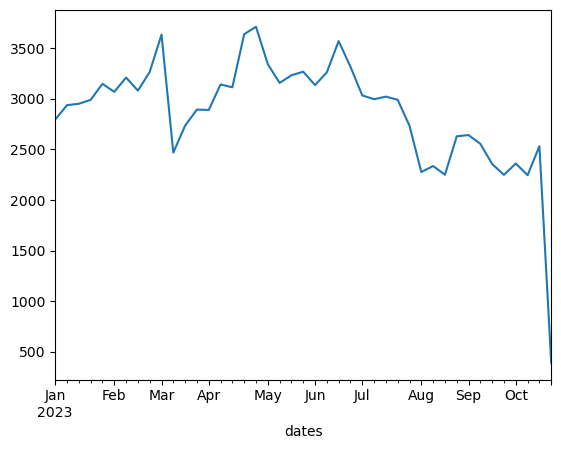

In [59]:
cplot_week['M3m']['2023':].plot()

## CHECKS: LNG send-outs  - Monthly

In [60]:
cplot = df.loc[~df['country'].str.startswith('GB')]

In [61]:
cplot_month =  cplot.groupby([pd.Grouper(freq='M'),'country']).sum(numeric_only=True).reset_index() #/converter

In [62]:
cplot_month['M3m'] = round(cplot_month['sendOut']/10.3,1)
print(cplot_month.tail())

         dates country  sendOut   stored  Max Storage  Max Sendout    M3m
939 2023-10-31      IT   6558.8  3718.69      7394.56       8964.8  636.8
940 2023-10-31      LT   1619.7  1246.12      2667.68       1860.1  157.3
941 2023-10-31      NL   9259.3  6780.86     11123.36      12291.2  899.0
942 2023-10-31      PL   2963.7  2267.85      5120.00       3520.0  287.7
943 2023-10-31      PT   2153.7  2470.34      6240.00       3200.0  209.1


In [63]:
cmonth = pd.pivot_table(cplot_month,values='M3m',index='dates',columns='country')

In [64]:
cmonth= cmonth['2021-01':'2023-09']

In [65]:
cmonth.columns

Index(['BE', 'DE', 'ES', 'ES*', 'FR', 'GR', 'HR', 'IT', 'LT', 'NL', 'PL',
       'PT'],
      dtype='object', name='country')

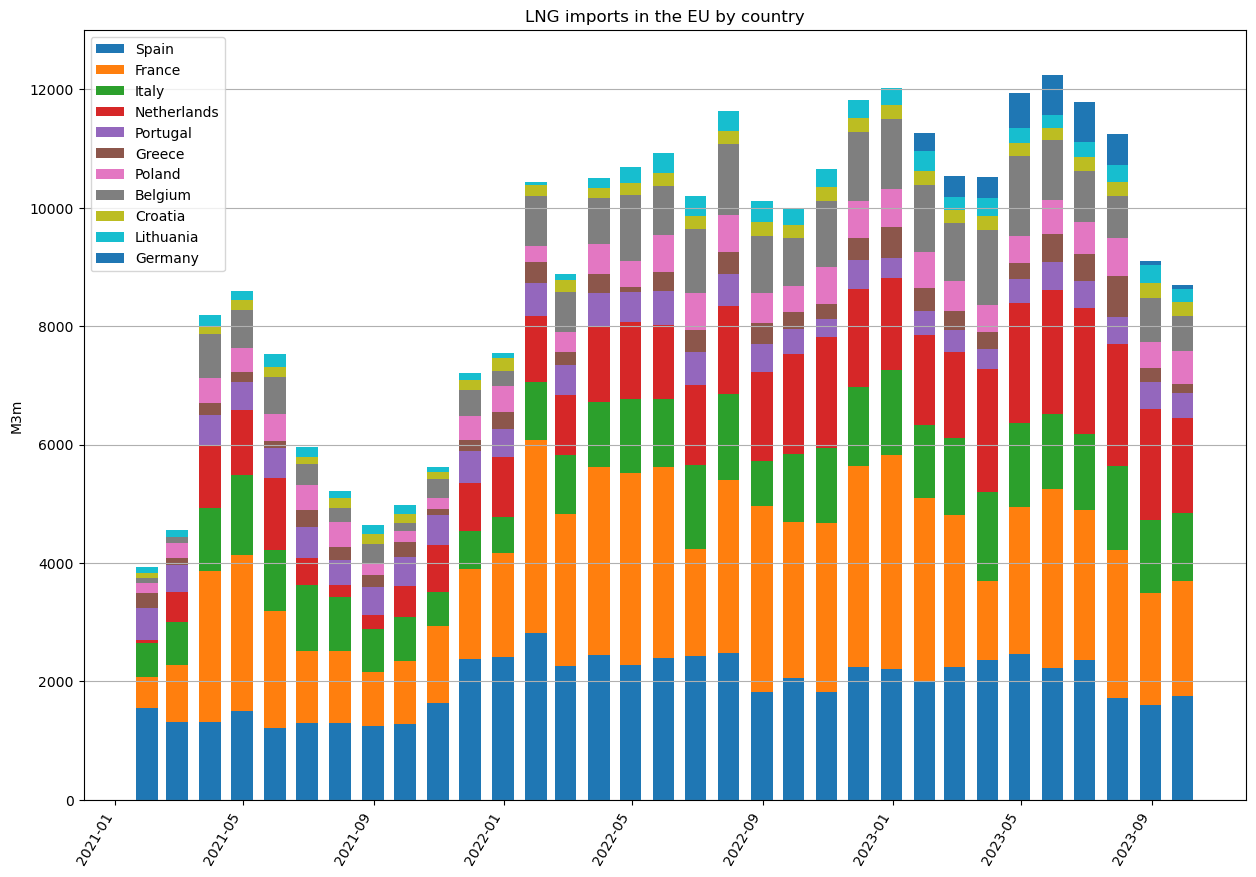

In [66]:
x = cmonth.index
width = 20       # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(15,10))

ax.bar(x, cmonth['ES*'], width, label='Spain')
ax.bar(x, cmonth['FR'], width, bottom=cmonth['ES*'],
       label='France')
ax.bar(x, cmonth['IT'], width, bottom=cmonth['ES*']+cmonth['FR'],
       label='Italy')
ax.bar(x, cmonth['NL'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT'],
       label='Netherlands')
ax.bar(x, cmonth['PT'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL'],
       label='Portugal')
ax.bar(x, cmonth['GR'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT'],
       label='Greece')
ax.bar(x, cmonth['PL'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR'],
       label='Poland')
ax.bar(x, cmonth['BE'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL'],
       label='Belgium')
ax.bar(x, cmonth['HR'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE'],
label='Croatia')
ax.bar(x, cmonth['LT'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE']+cmonth['HR'],
label='Lithuania')
ax.bar(x, cmonth['DE'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE']+cmonth['HR']+cmonth['LT'],
label='Germany')
fig.set_facecolor('white')

plt.setp(ax.get_xticklabels(), rotation=60, horizontalalignment='right')

ax = plt.gca()
ax.set_ylim([0, 13000])
ax.grid(axis='y')

ax.set_ylabel('M3m')
ax.set_title('LNG imports in the EU by country')
ax.legend(loc='upper left')

plt.show()

Weekly

In [74]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

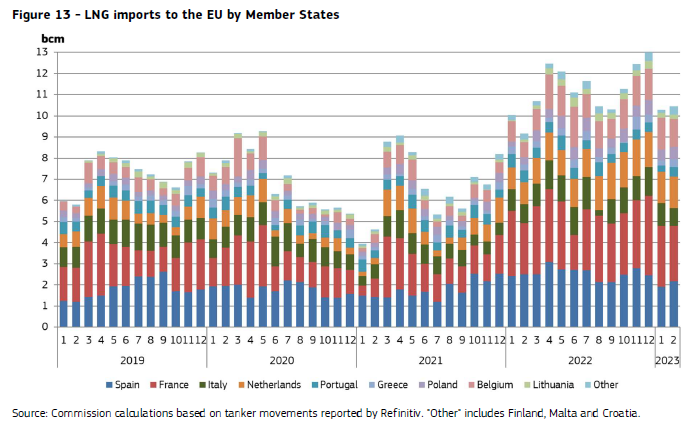

In [75]:
from IPython.display import Image, display
display(Image("Commission Qreport 2023.png",width=1200)) # to change after new Commission's gas report

#### checks for Spain

In [26]:
df[df['name']=='TVB (Virtual balancing LNG tank)']['sendOut']

dates
2020-07-09    790.9
2020-07-10    769.5
2020-07-11    677.7
2020-07-12    679.1
2020-07-13    729.5
              ...  
2023-10-12    596.1
2023-10-13    511.2
2023-10-14    521.7
2023-10-15    513.8
2023-10-16    674.2
Name: sendOut, Length: 1195, dtype: float64

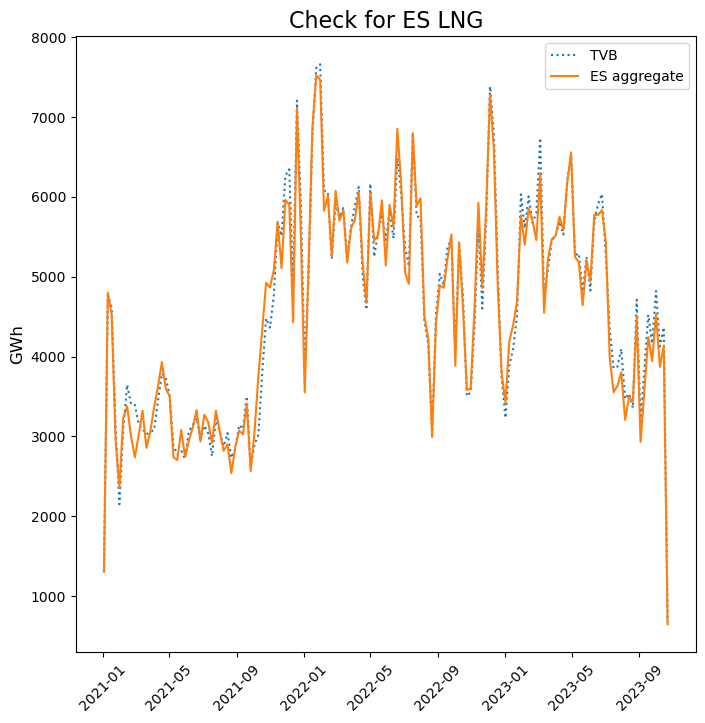

In [27]:
tvb = df[df['name']=='TVB (Virtual balancing LNG tank)']['2021':]
tvb_plot = tvb.groupby(pd.Grouper(freq='W'))['sendOut'].sum()
esp = df[df['country']=='ES']['2021':]
esp_plot = esp.groupby(pd.Grouper(freq='W'))['sendOut'].sum(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(tvb_plot,label='TVB',linestyle=':')
ax.plot(esp_plot,label='ES aggregate')

plt.xticks(rotation=45)
plt.title('Check for ES LNG',fontsize='16')
plt.ylabel('GWh',fontsize=12,loc='center')
plt.legend(loc='best')

In [40]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

In [41]:
df.country.unique()

array(['ES', 'IT', 'FR', 'NL', 'PT', 'GR', 'BE', 'GB', 'LT', 'PL', 'ES*',
       'GB*', 'HR', 'DE'], dtype=object)